## Problem Statement

Given a salary dataset with years of experience and the corresponding salary, use an ML model to predict new salary of people based on some different years of experience.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
 ds = pd.read_csv("data/Salary_Data.csv")
 ds.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [18]:
X = ds["YearsExperience"].values
Y = ds["Salary"].values

In [19]:
X

array([ 1.1,  1.3,  1.5,  2. ,  2.2,  2.9,  3. ,  3.2,  3.2,  3.7,  3.9,
        4. ,  4. ,  4.1,  4.5,  4.9,  5.1,  5.3,  5.9,  6. ,  6.8,  7.1,
        7.9,  8.2,  8.7,  9. ,  9.5,  9.6, 10.3, 10.5])

In [20]:
Y

array([ 39343,  46205,  37731,  43525,  39891,  56642,  60150,  54445,
        64445,  57189,  63218,  55794,  56957,  57081,  61111,  67938,
        66029,  83088,  81363,  93940,  91738,  98273, 101302, 113812,
       109431, 105582, 116969, 112635, 122391, 121872])

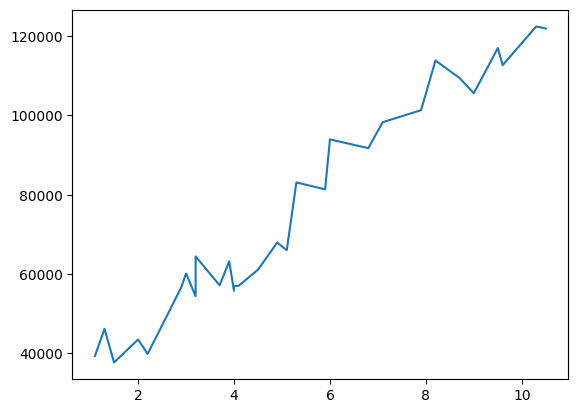

In [23]:
# Imp step to know which algorithm to use
plt.plot(X, Y)

Conversion to numpy array

In [28]:
X = np.array(X)
Y = np.array(Y)

Normalisation of the dataset

In [29]:
def mean(X):
    return np.sum(X)/len(X)

In [30]:
def variance(X):
    mean_value = mean(X)
    return np.sum((X-mean_value)**2)/len(X)

In [31]:
def norm(X):
    mean_value = mean(X)
    variance_value = variance(X)
    return (X - mean_value)/np.sqrt(variance_value)

In [32]:
X_norm = norm(X)
X_norm

array([-1.51005294, -1.43837321, -1.36669348, -1.18749416, -1.11581443,
       -0.86493538, -0.82909552, -0.75741579, -0.75741579, -0.57821647,
       -0.50653674, -0.47069688, -0.47069688, -0.43485702, -0.29149756,
       -0.1481381 , -0.07645838, -0.00477865,  0.21026054,  0.2461004 ,
        0.53281931,  0.6403389 ,  0.92705781,  1.03457741,  1.21377673,
        1.32129632,  1.50049564,  1.5363355 ,  1.78721455,  1.85889428])

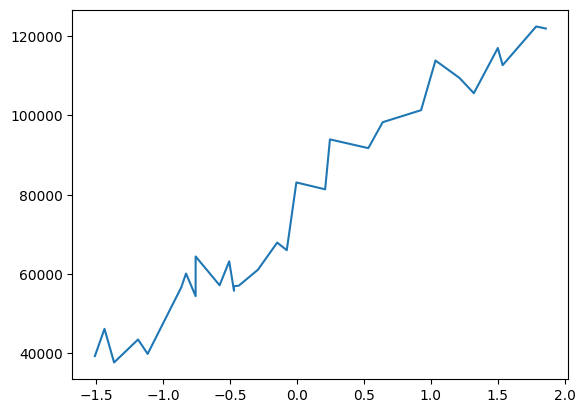

In [33]:
plt.plot(X_norm, Y)

learning rate, max iterations, threshold value.
weight a and bias b 

In [36]:
import random

In [40]:
class SimpleLR:
    def __init__(self, lr=0.1, max_iter=2000, threshold=1e-6):
        self.lr = lr
        self.max_iter = max_iter
        self.threshold = threshold
        self.weight = random.uniform(-1,1)
        self.bias = random.uniform(-1,1)

    def predict(self, X):
        return self.weight*X + self.bias

    # Return loss history and help us understand how losses are performing.
    def fit(self, X, Y):
        n = len(X)
        loss_history = []
        y_pred = self.predict(X)
        errors = Y-y_pred
        prev_loss = (1/(2*n)) * np.sum(errors**2)
        loss_history.append(prev_loss)

        for i in range(self.max_iter):
            w_grad = (1/n) * np.sum(errors*X)
            b_grad = (1/n) * np.sum(errors)
            self.weight += self.lr * w_grad
            self.bias += self.lr * b_grad
            y_pred = self.predict(X)
            errors = Y-y_pred
            curr_loss = (1/(2*n)) * np.sum(errors**2)

            if np.abs(curr_loss - prev_loss) < self.threshold:
                break
            prev_loss = curr_loss
            loss_history.append(curr_loss)
        return loss_history

    def plot(self, X, Y):
        y_pred = self.predict(X)
        plt.plot(X, Y)
        plt.plot(X, y_pred)

In [41]:
model = SimpleLR()

In [42]:
loss_history = model.fit(X_norm, Y)

In [43]:
loss_history

[np.float64(3251498038.643548),
 np.float64(2636684151.7148905),
 np.float64(2138684903.3026783),
 np.float64(1735305512.088786),
 np.float64(1408568205.205533),
 np.float64(1143910986.6300983),
 np.float64(929538639.5839965),
 np.float64(755897038.4766542),
 np.float64(615247341.5797064),
 np.float64(501321087.09317887),
 np.float64(409040820.95909154),
 np.float64(334293805.3904808),
 np.float64(273748722.77990615),
 np.float64(224707205.86534062),
 np.float64(184983577.16454262),
 np.float64(152807437.91689622),
 np.float64(126744765.12630254),
 np.float64(105634000.16592179),
 np.float64(88534280.5480133),
 np.float64(74683507.65750742),
 np.float64(63464381.61619773),
 np.float64(54376889.52273688),
 np.float64(47016020.92703357),
 np.float64(41053717.36451393),
 np.float64(36224251.47887298),
 np.float64(32312384.11150381),
 np.float64(29143771.543934785),
 np.float64(26577195.36420385),
 np.float64(24498268.65862183),
 np.float64(22814338.027100343),
 np.float64(21450354.2155679

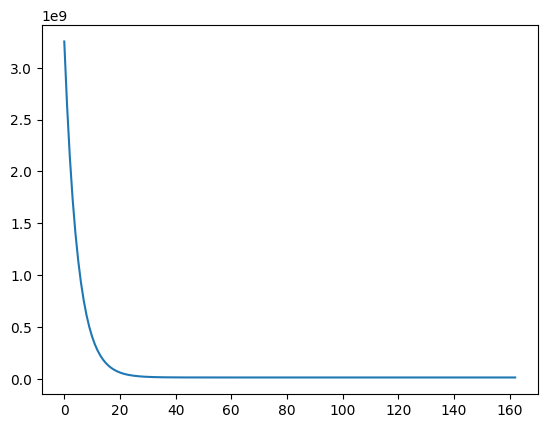

In [44]:
plt.plot(loss_history)

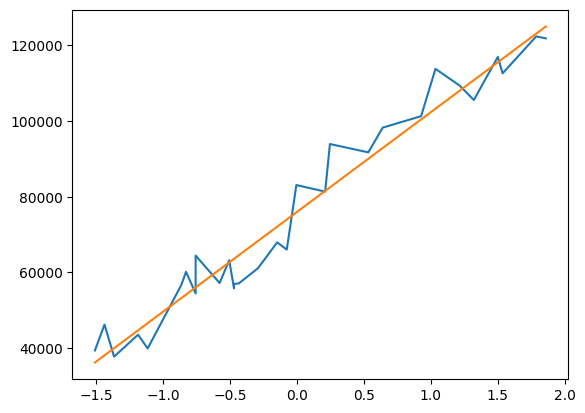

In [46]:
model.plot(X_norm, Y)